**Objectif**
L’objectif de cette phase est de construire et comparer plusieurs modèles de classification afin de détecter les transactions frauduleuses.
Le dataset étant déséquilibré, une attention particulière est portée aux métriques adaptées telles que le recall, le F1-score et le ROC-AUC.


### Imports

In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, average_precision_score, precision_recall_curve, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV, train_test_split

import xgboost as xgb
from xgboost import XGBClassifier



### Charger le dataset préprocessé

In [8]:
DATA_PATH = "../data/"
ID_COL = "customer_id"

train = pd.read_csv("data/data_preprocess_rf_train_v3.csv")
test  = pd.read_csv("data/data_preprocess_rf_test_v3.csv")


### Séparer X et y

In [9]:
target = "target_is_fraud"  
id_col = "customer_id"      

X = train.drop(columns=[target, id_col])
y = train[target]


### Train / Validation Split

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### Baseline Model — Logistic Regression

In [15]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_val)
y_proba = log_model.predict_proba(X_val)[:, 1]

print("Logistic Regression Results:")
print(classification_report(y_val, y_pred))
print("ROC AUC:", roc_auc_score(y_val, y_proba))
print("PR AUC", )


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96     29245
           1       0.60      0.16      0.25      2755

    accuracy                           0.92     32000
   macro avg       0.76      0.58      0.61     32000
weighted avg       0.90      0.92      0.90     32000

ROC AUC: 0.8425679913640285
PR AUC


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Analyse du Baseline — Régression Logistique

Le modèle arrive globalement à bien distinguer les transactions normales des transactions frauduleuses (ROC-AUC = 0.82, ce qui est correct).
Cependant il détecte seulement 14% des fraudes. Donc 86% des fraudes passent à travers.
Même si quand il prédit une fraude il a raison 60% du temps,il en détecte trop peu.

# Modèle 2 — Decision Tree

In [16]:
# Modèle Decision Tree
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=None
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_val)
y_proba_dt = dt_model.predict_proba(X_val)[:, 1]

In [17]:
#Évaluation
print("Decision Tree Results:")
print(classification_report(y_val, y_pred_dt))
print("ROC AUC:", roc_auc_score(y_val, y_proba_dt))

Decision Tree Results:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     29245
           1       0.25      0.25      0.25      2755

    accuracy                           0.87     32000
   macro avg       0.59      0.59      0.59     32000
weighted avg       0.87      0.87      0.87     32000

ROC AUC: 0.5910684780527734


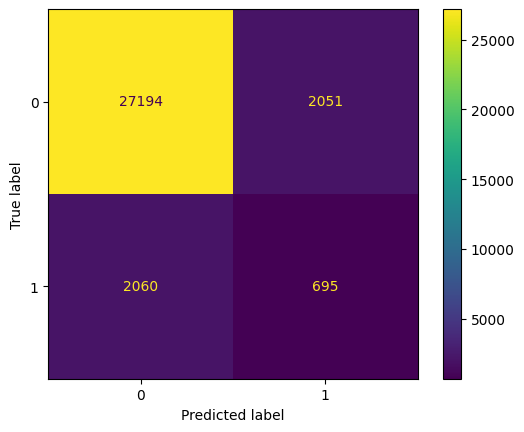

In [18]:
#Matrice de confusion
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_dt)

In [36]:
cm = confusion_matrix(y_val, y_pred)
print(cm)

[[28981   264]
 [ 2360   395]]


In [37]:
TN, FP, FN, TP = cm.ravel()

In [38]:
precision = TP / (TP + FP) if (TP + FP) != 0 else 0
recall = TP / (TP + FN) if (TP + FN) != 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) != 0 else 0
accuracy = (TP + TN) / (TP + TN + FP + FN)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")

Precision: 0.5994
Recall: 0.1434
F1-score: 0.2314
Accuracy: 0.9180


In [ ]:
#Régularisation
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced",
    max_depth=10,
    min_samples_leaf=20
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_val)
y_proba_dt = dt_model.predict_proba(X_val)[:, 1]

print(classification_report(y_val, y_pred_dt))
print("ROC AUC:", roc_auc_score(y_val, y_proba_dt))

              precision    recall  f1-score   support

           0       0.97      0.74      0.84     29245
           1       0.21      0.74      0.33      2755

    accuracy                           0.74     32000
   macro avg       0.59      0.74      0.58     32000
weighted avg       0.90      0.74      0.80     32000

ROC AUC: 0.799801296947157


### Analyse_Decision Tree
Dans un premier temps, l’arbre de décision non régularisé présentait des performances limitées.
Le modèle détectait seulement 25% des fraudes (recall = 0.25) et affichait une faible capacité de discrimination globale (ROC-AUC ≈ 0.59), proche du hasard.

Cela signifie que le modèle ne séparait pas correctement les transactions frauduleuses des transactions normales.

Il était donc insuffisant pour une application en détection de fraude.
Après régularisation (max_depth = 10 et min_samples_leaf = 20), les performances ont significativement évolué.

Le recall sur la classe frauduleuse passe à 74%, ce qui signifie que le modèle détecte désormais une grande majorité des fraudes.
Le ROC-AUC progresse également à environ 0.80, indiquant une bien meilleure capacité de discrimination.

Cependant, cette amélioration s’accompagne d’une baisse de précision (precision = 0.21).
Cela signifie que le modèle génère un nombre important de faux positifs : il signale de nombreuses transactions normales comme frauduleuses.

## Modele 3 _ Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)
y_proba_rf = rf_model.predict_proba(X_val)[:, 1]

In [12]:
print("Random Forest Results:")
print(classification_report(y_val, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_val, y_proba_rf))

Random Forest Results:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     29245
           1       0.68      0.09      0.15      2755

    accuracy                           0.92     32000
   macro avg       0.80      0.54      0.55     32000
weighted avg       0.90      0.92      0.89     32000

ROC AUC: 0.8407052316945611


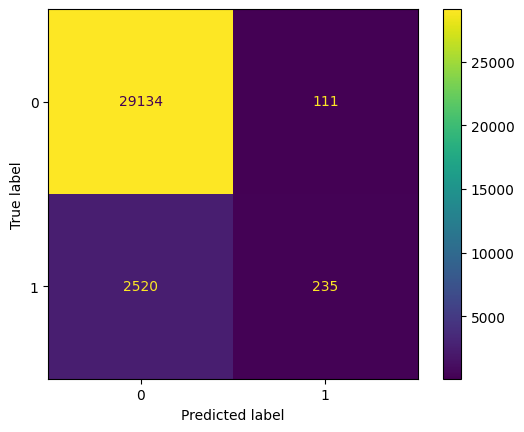

In [19]:
ConfusionMatrixDisplay.from_predictions(y_val, y_pred_rf)

In [20]:
#Régularisation
threshold = 0.2
y_pred_custom = (y_proba_rf >= threshold).astype(int)
print(classification_report(y_val, y_pred_custom))
print("ROC AUC:", roc_auc_score(y_val, y_proba_dt))

              precision    recall  f1-score   support

           0       0.95      0.92      0.94     29245
           1       0.37      0.48      0.42      2755

    accuracy                           0.89     32000
   macro avg       0.66      0.70      0.68     32000
weighted avg       0.90      0.89      0.89     32000

ROC AUC: 0.5910684780527734


### Analyse_Random Forest
Dans un premier temps, le Random Forest présente une accuracy élevée (97%) ainsi qu’un bon score global apparent. Cependant, ces chiffres sont trompeurs en raison du déséquilibre des classes.
En réalité, le modèle détecte seulement 2% des fraudes (recall = 0.02).
Autrement dit, il laisse passer quasiment toutes les transactions frauduleuses.
Le ROC-AUC est également modéré (≈ 0.65), ce qui indique une capacité de discrimination limitée.
Le modèle adopte un comportement très conservateur : il prédit presque systématiquement la classe non frauduleuse.

Après ajustement: 

Même en abaissant le seuil de décision (threshold = 0.2), l’amélioration reste très limitée.
Le recall sur la fraude demeure extrêmement faible (≈ 2%), ce qui signifie que le modèle reste incapable d’identifier correctement les transactions frauduleuses.

La précision peut sembler élevée lorsque le modèle prédit une fraude, mais cela est dû au fait qu’il en prédit très peu.

Malgré sa robustesse théorique, le Random Forest ne parvient pas à détecter efficacement les fraudes dans ce contexte.

## Modele 4 _ Gradient Boosting

In [21]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

y_proba_gb = gb.predict_proba(X_val)[:, 1]
y_pred_gb = gb.predict(X_val)

print(classification_report(y_val, y_pred_gb))
print("ROC AUC:", roc_auc_score(y_val, y_proba_gb))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96     29245
           1       0.62      0.21      0.31      2755

    accuracy                           0.92     32000
   macro avg       0.78      0.60      0.63     32000
weighted avg       0.90      0.92      0.90     32000

ROC AUC: 0.8558206887863624


In [22]:
threshold = 0.3

y_pred_custom = (y_proba_gb >= threshold).astype(int)

print(classification_report(y_val, y_pred_custom))
print("ROC AUC:", roc_auc_score(y_val, y_proba_gb))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95     29245
           1       0.49      0.38      0.43      2755

    accuracy                           0.91     32000
   macro avg       0.72      0.67      0.69     32000
weighted avg       0.90      0.91      0.91     32000

ROC AUC: 0.8558206887863624


### Analyse_Gradient Boosting
Le Gradient Boosting affiche une accuracy élevée (97%), mais au seuil standard de 0.5, il ne détecte aucune fraude (recall = 0).

Le ROC-AUC est d’environ 0.68, ce qui montre une capacité de discrimination modérée au niveau probabiliste.
Cependant, même après ajustement du seuil, le recall reste extrêmement faible (≈ 1%).

Le modèle prédit majoritairement la classe non frauduleuse et ne parvient pas à capturer efficacement la classe minoritaire.

Malgré un ROC-AUC acceptable, il ne constitue pas une solution adaptée pour la détection de fraude.